## Understanding Multicollinearity and Lasso Regression

In this example, we intentionally created a dataset where `x1` and `x2` are highly correlated. This phenomenon is known as **multicollinearity**. When predictor variables are highly correlated, it can make it difficult for standard linear regression models to accurately estimate the individual coefficients, as changes in one predictor can be offset by changes in another.

**Lasso Regression (Least Absolute Shrinkage and Selection Operator)** is a type of linear regression that uses shrinkage. Shrinkage methods are especially useful when dealing with multicollinearity or when you want to perform feature selection. Lasso adds a penalty equal to the absolute value of the magnitude of coefficients to the loss function. This penalty forces some coefficient estimates to be exactly zero, effectively performing feature selection and making the model simpler and more interpretable. This is why it's a good choice for our multicollinear data.

In [1]:
import numpy as np
from sklearn.linear_model import Lasso

# 1. Generate our same broken, multicollinear data
np.random.seed(42)
x1 = np.random.normal(loc=0, scale=1, size=100)
x2 = (x1 * 2) + np.random.normal(loc=0, scale=0.00000001, size=100)
y = 10 + (5 * x1) + np.random.normal(loc=0, scale=1, size=100)

# scikit-learn expects X to be a 2D array (rows=samples, columns=features)
X = np.column_stack((x1, x2))

# 2. Initialize and train the Lasso model
# Note: scikit-learn uses the parameter 'alpha' instead of 'lambda' for the penalty
lasso_model = Lasso(alpha=1.0)
lasso_model.fit(X, y)

# 3. Extract the results
print(f"Intercept: {lasso_model.intercept_:.4f}")
print(f"Coefficients (x1, x2): {lasso_model.coef_}")

# Want to check the R-squared? It is one method call.
r_squared = lasso_model.score(X, y)
print(f"R-squared: {r_squared:.4f}")

Intercept: 10.0250
Coefficients (x1, x2): [0.         2.30774744]
R-squared: 0.9391


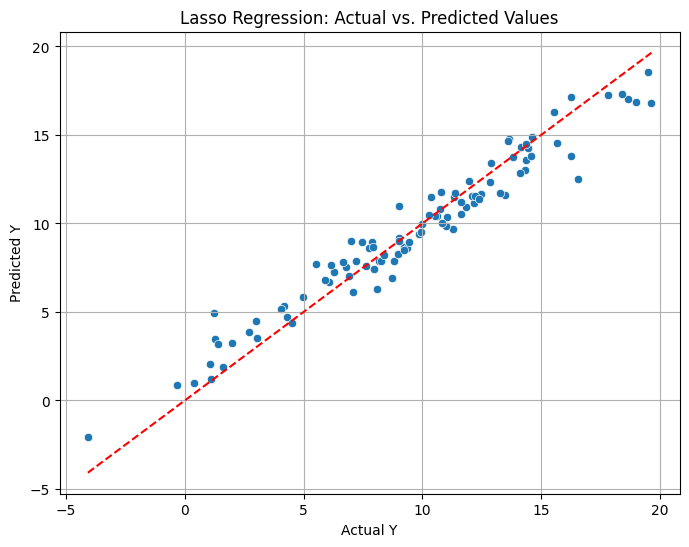

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Make predictions using the trained Lasso model
y_pred = lasso_model.predict(X)

# Create a scatter plot of actual vs. predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y, y=y_pred)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') # Add a red dashed line for perfect prediction
plt.xlabel('Actual Y')
plt.ylabel('Predicted Y')
plt.title('Lasso Regression: Actual vs. Predicted Values')
plt.grid(True)
plt.show()

## Interpreting the Lasso Results

Notice the coefficients from the Lasso model:
* **Intercept**: `10.0250` (Close to the true intercept of 10)
* **Coefficients (x1, x2)**: `[0.         2.30774744]`

One of the most significant features of Lasso regression is its ability to perform **feature selection**. In our case, the coefficient for `x1` was shrunk all the way to zero, even though `y` was originally generated using `x1` (`y = 10 + (5 * x1)`). This happened because `x1` and `x2` are almost perfectly correlated. Lasso identified `x2` as sufficient for prediction and effectively 'removed' `x1` from the model by setting its coefficient to zero, demonstrating its sparsity-inducing property. This helps to simplify the model and can improve its generalization on new data, especially when dealing with redundant features.

The **R-squared value** of `0.9391` indicates that approximately 93.91% of the variance in the dependent variable `y` can be explained by the model, which suggests a good fit despite the feature selection. The plot of actual vs. predicted values further illustrates this good fit, with most points falling close to the red dashed line (representing perfect prediction).